In [1]:
import os
os.getcwd()

'c:\\Users\\giovanni.sgaravatti\\Bruegel Gitlab\\2021-11-european-natural-gas-imports'

In [2]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports'

In [3]:
os.chdir(Share_point)

In [4]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

import eurostat  # python wrapper for taking data.
import time

In [5]:
# Converter for metric tonnes to M3m 
converter = -0.001379

### In Million tonnes

In [6]:
d1 = pd.read_excel('raw_data/LNG/Global LNG imports 2017-2018.xlsx')
d2 = pd.read_excel('raw_data/LNG/Global LNG imports 2019-2020.xlsx')
d3 = pd.read_excel('raw_data/LNG/Global LNG imports 2021-2022.xlsx')
d4 = pd.read_excel('raw_data/LNG/Global LNG imports 2023.xlsx')

In [7]:
# Merge 2017 to 2020
df_20 = pd.merge(d1,d2,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [8]:
# Merge 2017 to 2022
df_22 = pd.merge(df_20,d3,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [9]:
# Merge 2022 to 2023
df = pd.merge(df_22,d4,on=['Origin_Berthcountry','Port_Country'],how='outer')

## little code to investigate total global flows

### Belgium transhipping checks

In [85]:
# check who imports from BE
df[df['Origin_Berthcountry']=='Belgium'].iloc[:, :2].join(df[df['Origin_Berthcountry']=='Belgium'].iloc[:, -9:])

,Port_Country,Origin_Berthcountry,2023-09-30 00:00:00,2023-08-31 00:00:00,2023-07-31 00:00:00,2023-06-30 00:00:00,2023-05-31 00:00:00,2023-04-30 00:00:00,2023-03-31 00:00:00,2023-02-28 00:00:00,2023-01-31 00:00:00
18,Brazil,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,Bunkering,Belgium,-2759.85,-2759.85,-2757.15,NaN,NaN,-3204.9,-3171.15,-3211.65,NaN
77,Finland,Belgium,-3280.95,NaN,NaN,-3195.0,NaN,NaN,NaN,NaN,NaN
99,India,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
183,Lithuania,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217,Norway,Belgium,-3280.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245,Portugal,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
287,Spain,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
299,Sweden,Belgium,NaN,-6589.35,NaN,-6582.6,NaN,NaN,NaN,NaN,NaN
386,Bangladesh,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
lng_i = pd.DataFrame()
for country in ['Belgium','France','Spain']:
    lng_i['{}'.format(country)] = df[df['Port_Country']==country].sum(numeric_only=True)*converter*10.3/1000

In [87]:
lng_i.to_excel(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2023-04 How the EU can phase out Russian LNG\Data\lng_BB.xlsx')

## EU27

In [154]:
EU27 = ['Belgium', 'Croatia','Finland','France','Greece','Italy','Lithuania','Netherlands', 'Portugal','Spain','Sweden'] #, 'United Kingdom']

In [155]:
eu = df[df['Port_Country'].isin(EU27)].reset_index()

In [177]:
eu27 = eu.groupby('Origin_Berthcountry').sum()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_972\938639950.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  eu27 = eu.groupby('Origin_Berthcountry').sum()


In [178]:
del eu27['index']

In [179]:
eu27.columns=pd.to_datetime(eu27.columns)

In [191]:
eu27_t = eu27.T

In [194]:
eu27_t=eu27_t.sort_index()

In [208]:
eu27_t.replace(0,np.nan,inplace=True)
df27=eu27_t.iloc[-9:,:].dropna(axis=1,how='all')

In [209]:
# convert to TWh
df27=df27*converter*10.3/1000 

In [211]:
df27.columns

Index(['Algeria', 'Angola', 'Belgium', 'Brazil', 'Cameroon', 'Egypt',
       'Equatorial Guinea', 'France', 'Indonesia', 'Lithuania', 'Mozambique',
       'Netherlands', 'Nigeria', 'Norway', 'Oman', 'Peru', 'Qatar', 'Russia',
       'Spain', 'Trinidad & Tobago', 'United States of America'],
      dtype='object', name='Origin_Berthcountry')

In [215]:
df27[['Russia','United States of America','Qatar','Norway','Trinidad & Tobago','Nigeria']]

Origin_Berthcountry,Russia,United States of America,Qatar,Norway,Trinidad & Tobago,Nigeria
2023-01-31,15.684283,38.195503,13.971649,4.495175,0.403857,9.414999
2023-02-28,19.754463,40.632575,11.735653,1.710863,3.890773,3.600252
2023-03-31,14.994488,43.752641,10.873469,4.594457,0.940054,10.178279
2023-04-30,16.099275,56.159009,15.099292,4.452773,1.417205,9.419480
2023-05-31,17.872463,46.889350,14.418062,3.649391,1.447731,9.918413
2023-06-30,13.838076,44.361466,14.420868,3.451378,2.982977,7.010052
2023-07-31,16.098169,41.979689,14.857023,4.742641,3.988846,6.174035
2023-08-31,11.974976,48.417412,15.560381,4.367067,2.559811,7.769139
2023-09-30,11.979623,38.118612,8.447448,2.665478,1.019062,8.105398


### Single-out China

In [88]:
china = df[df['Port_Country'].isin(['China'])].reset_index()

In [89]:
cols = china.iloc[:,1:3]

In [90]:
cols.tail()

,Port_Country,Origin_Berthcountry
25,China,China
26,China,India
27,China,United Arab Emirates
28,China,Spain
29,China,Mozambique


In [91]:
# convert to M3m
values = china.iloc[:,3:]*converter

In [92]:
china = pd.concat([cols,values], axis=1)

In [93]:
china = china.groupby(['Origin_Berthcountry']).sum(numeric_only=True)

In [94]:
china = china.T #drop(

In [95]:
china.index = pd.to_datetime(china.index)
china = china.sort_index()

In [96]:
china.head()

Origin_Berthcountry,Algeria,Angola,Australia,Belgium,Brunei Darussalam,Cameroon,China,Egypt,Equatorial Guinea,France,...,Peru,Qatar,Russia,Singapore,South Korea,Spain,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America
2017-01-31,0.000000,0.000000,1442.578933,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,1365.703337,85.989614,0.000000,0.0,0.0,97.724214,0.0,0.0,177.383597
2017-02-28,0.000000,0.000000,1204.069299,0.0,0.0,0.0,0.0,0.0,97.879972,0.000000,...,0.0,723.682928,0.000000,90.064145,0.0,0.0,0.000000,0.0,0.0,97.139035
2017-03-31,0.000000,90.447024,1469.011881,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,396.821247,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,194.999770
2017-04-30,0.000000,90.756679,1295.838716,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,637.936570,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,90.336566
2017-05-31,77.628943,89.909007,2078.578766,0.0,0.0,0.0,0.0,0.0,0.000000,86.613266,...,0.0,623.982262,85.008524,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000


<Axes: title={'center': 'LNG imports in China'}, ylabel='M3m'>

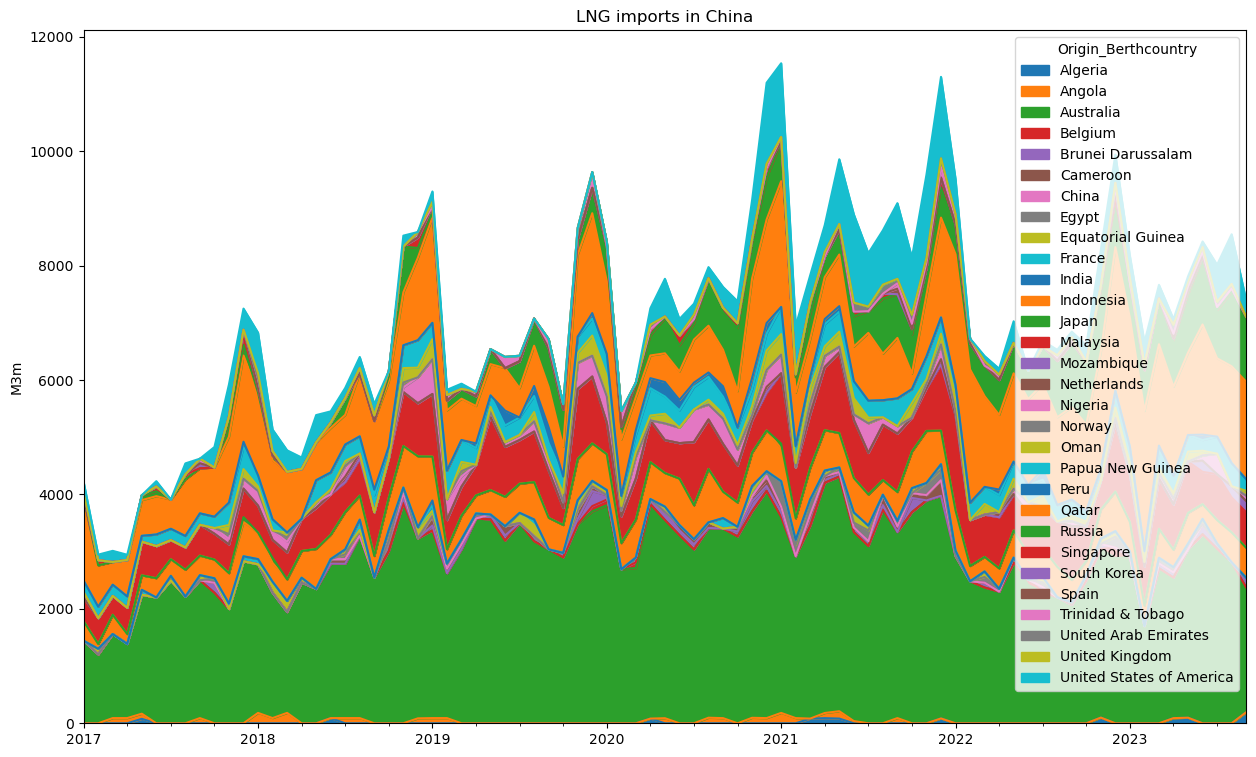

In [97]:
china.plot(figsize=(15, 9),kind='area',ylabel='M3m', title='LNG imports in China')

In [98]:
col = china.columns

In [99]:
china['Total'] = china.sum(axis=1)

In [100]:
# percentage increase in chinese LNG imports
(china['Total']['2023-01':'2023-09'].sum()/china['Total']['2022-01':'2022-09'].sum()-1)*100

12.29794257282939

In [101]:
china.columns

Index(['Algeria', 'Angola', 'Australia', 'Belgium', 'Brunei Darussalam',
       'Cameroon', 'China', 'Egypt', 'Equatorial Guinea', 'France', 'India',
       'Indonesia', 'Japan', 'Malaysia', 'Mozambique', 'Netherlands',
       'Nigeria', 'Norway', 'Oman', 'Papua New Guinea', 'Peru', 'Qatar',
       'Russia', 'Singapore', 'South Korea', 'Spain', 'Trinidad & Tobago',
       'United Arab Emirates', 'United Kingdom', 'United States of America',
       'Total'],
      dtype='object', name='Origin_Berthcountry')

In [102]:
## Define an "Other" category
china['Other']= china.loc[:, ~china.columns.isin(['Total','Russia','Australia','United States of America','Qatar','Indonesia','Malaysia'])].sum(axis=1)

In [103]:
china_r = china[['Russia','Australia','Qatar','United States of America','Indonesia','Malaysia','Other']]

In [104]:
china_twh = china_r*10.3/1000

<Axes: title={'center': 'LNG imports in China'}, ylabel='TWh'>

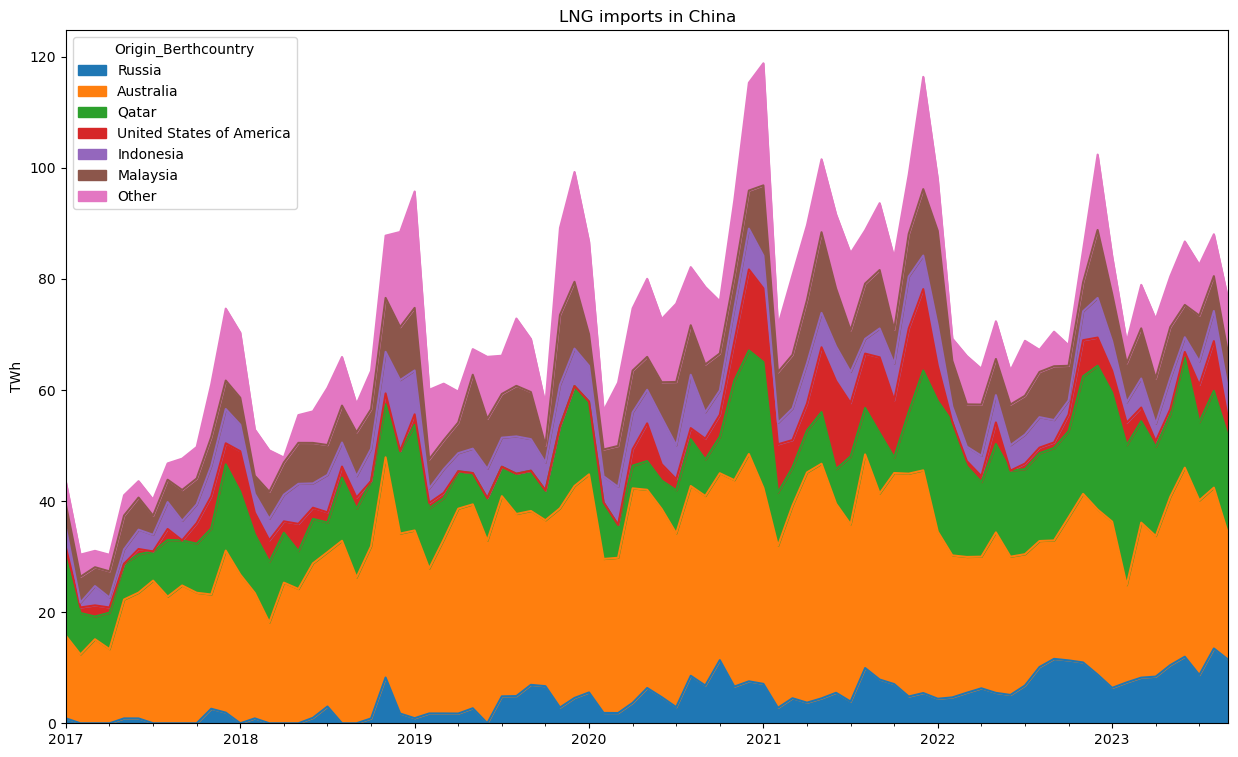

In [105]:
china_twh.plot(figsize=(15, 9),kind='area',ylabel='TWh', title='LNG imports in China')

## Single out Russia

In [10]:
## Here we get 
russia = df[df['Origin_Berthcountry'].isin(['Russia'])].reset_index()

In [11]:
cols = russia.iloc[:,1]

In [12]:
values = russia.iloc[:,3:]*converter

In [20]:
russia = pd.concat([cols,values], axis=1)

In [21]:
russia = russia.groupby(['Port_Country']).sum(numeric_only=True)

In [23]:
dfint = russia.iloc[:,-9:].replace(0, np.nan).dropna(how='all')

In [24]:
dfint = dfint/1000*10.3 # convert in TWh

In [26]:
dfint.to_excel(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG\Bloomberg\russia.xlsx')

In [16]:
russia = russia.T

In [17]:
russia.index = pd.to_datetime(russia.index)
russia = russia.sort_index()

In [114]:
russia.columns

Index(['Argentina', 'Bangladesh', 'Belgium', 'Brazil', 'Bunkering', 'Canada',
       'China', 'Croatia', 'Dominican Republic', 'Egypt', 'Finland', 'France',
       'Greece', 'India', 'Indonesia', 'Israel', 'Italy', 'Japan', 'Jordan',
       'Kuwait', 'Lithuania', 'Netherlands', 'Norway', 'Pakistan', 'Panama',
       'Portugal', 'Puerto Rico', 'Russia', 'Singapore', 'South Korea',
       'Spain', 'Sweden', 'Taiwan', 'Thailand', 'Turkey',
       'United Arab Emirates', 'United Kingdom', 'United States of America'],
      dtype='object', name='Port_Country')

In [115]:
russia_c = russia

In [116]:
EU28 = ['Belgium', 'Croatia','Finland','France','Greece','Italy','Lithuania','Netherlands', 'Portugal','Spain','Sweden'] #, 'United Kingdom']
russia_c['EU28']= russia_c.loc[:, russia_c.columns.isin(EU28)].sum(axis=1)

In [117]:
russia_c['RoW'] = russia_c.loc[:, ~russia_c.columns.isin(EU28+ ['China','EU28'])].sum(axis=1)

In [118]:
russia_c.columns

Index(['Argentina', 'Bangladesh', 'Belgium', 'Brazil', 'Bunkering', 'Canada',
       'China', 'Croatia', 'Dominican Republic', 'Egypt', 'Finland', 'France',
       'Greece', 'India', 'Indonesia', 'Israel', 'Italy', 'Japan', 'Jordan',
       'Kuwait', 'Lithuania', 'Netherlands', 'Norway', 'Pakistan', 'Panama',
       'Portugal', 'Puerto Rico', 'Russia', 'Singapore', 'South Korea',
       'Spain', 'Sweden', 'Taiwan', 'Thailand', 'Turkey',
       'United Arab Emirates', 'United Kingdom', 'United States of America',
       'EU28', 'RoW'],
      dtype='object', name='Port_Country')

In [120]:
# EU imports from Russia in TWh 
russia_c['EU28']['2022'].sum()/1000*10.3

194.714244435375

In [121]:
# percentage going to the EU
russia_c['EU28']['2023'].sum()/(russia_c['RoW']['2023'].sum()+russia_c['EU28']['2023'].sum()+russia_c['China']['2023'].sum())*100

43.47602350621634

In [122]:
russia_p = russia_c[['China', 'EU28','RoW']]

<Axes: title={'center': 'LNG exports from Russia'}, ylabel='M3m'>

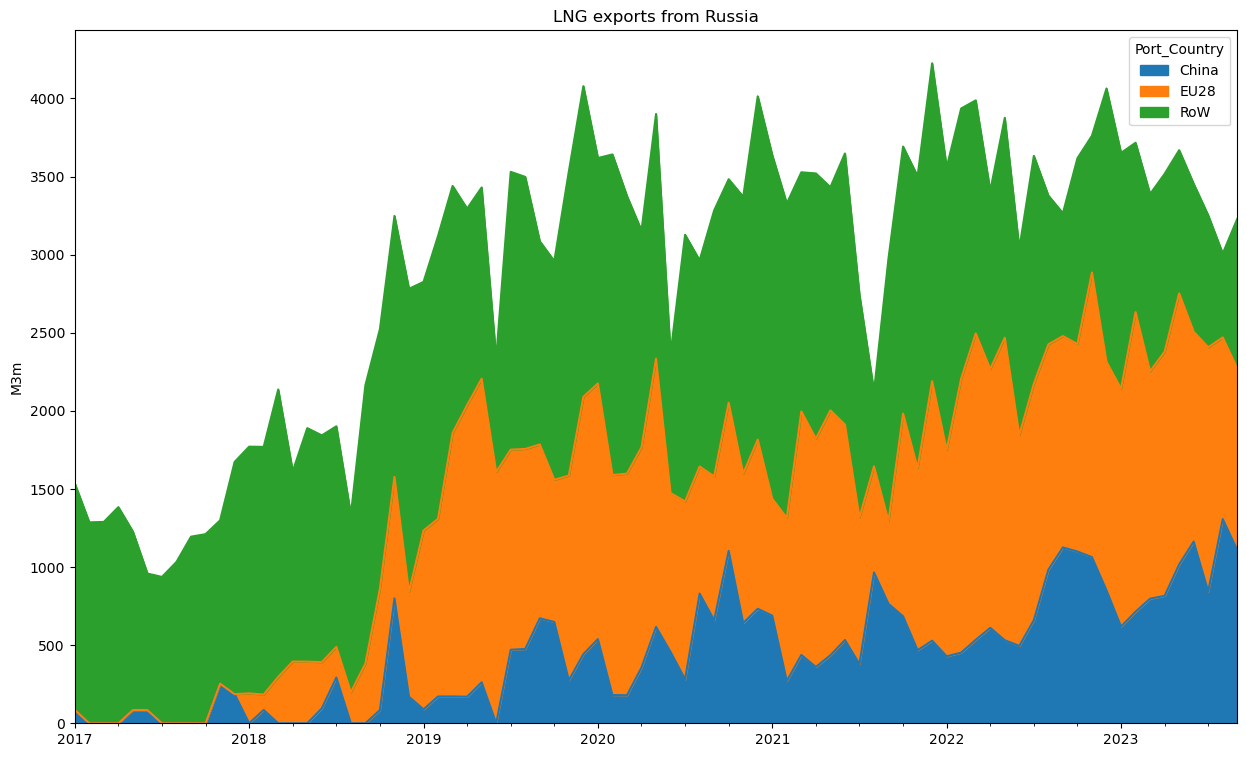

In [123]:
russia_p.plot(figsize=(15, 9),kind='area',ylabel='M3m', title='LNG exports from Russia')

In [124]:
russia_twh = russia_p/1000*10.3

<Axes: title={'center': 'LNG exports from Russia'}, ylabel='TWh'>

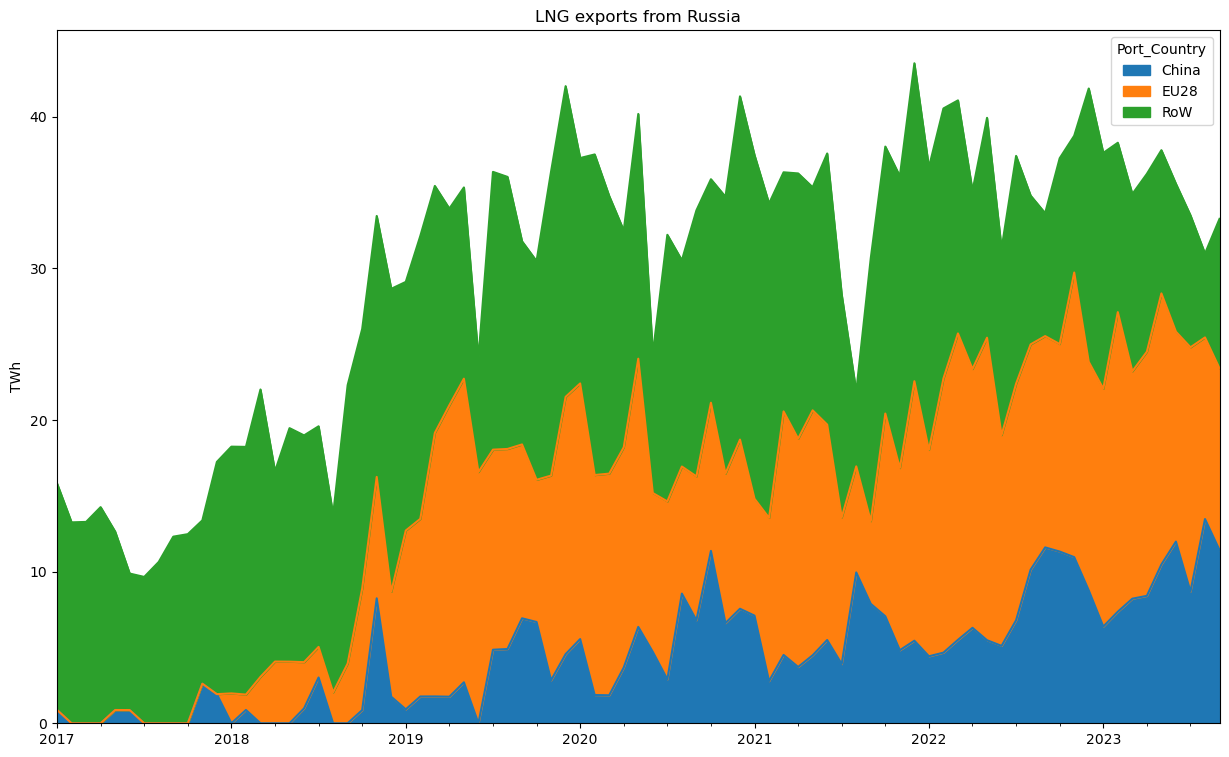

In [125]:
russia_twh.plot(figsize=(15, 9),kind='area',ylabel='TWh', title='LNG exports from Russia')

In [51]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\Imports'

In [52]:
russia_twh.to_excel(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2023-04 How the EU can phase out Russian LNG\Data\Russian exports 06.06.xlsx')